# Transactions Finance

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib as plt
import seaborn as sns
import json

## Loading CSV Data

In [2]:
transactions = pd.read_csv("transactions_data.csv")
users = pd.read_csv("users_data.csv")
cards = pd.read_csv("cards_data.csv")

## Load Json files

In [3]:
with open("mcc_codes.json", "r") as f:
    data = json.load(f)

mcc = pd.DataFrame(
    data.items(),
    columns=["MCC_Code", "MCC_Description"]
)

mcc["MCC_Code"] = mcc["MCC_Code"].astype(int)
mcc.to_csv(
    "mcc.csv",
    index= False
)

In [4]:

with open("train_fraud_labels.json", "r") as f:
    data = json.load(f)

fraud = (
    pd.DataFrame(
        data["target"].items(),
        columns=["transaction_id", "Fraud_Status"]
    )
)

fraud["transaction_id"] = fraud["transaction_id"].astype(int)

fraud.head()

,transaction_id,Fraud_Status
0,10649266,No
1,23410063,No
2,9316588,No
3,12478022,No
4,9558530,No


## Data Exploration

In [5]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            str    
 2   client_id       int64  
 3   card_id         int64  
 4   amount          str    
 5   use_chip        str    
 6   merchant_id     int64  
 7   merchant_city   str    
 8   merchant_state  str    
 9   zip             float64
 10  mcc             int64  
 11  errors          str    
dtypes: float64(1), int64(5), str(6)
memory usage: 1.2 GB


In [6]:
fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 2 columns):
 #   Column          Dtype
---  ------          -----
 0   transaction_id  int64
 1   Fraud_Status    str  
dtypes: int64(1), str(1)
memory usage: 136.0 MB


In [7]:
mcc.info()

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   MCC_Code         109 non-null    int64
 1   MCC_Description  109 non-null    str  
dtypes: int64(1), str(1)
memory usage: 1.8 KB


In [8]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   str    
 6   address            2000 non-null   str    
 7   latitude           2000 non-null   float64
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   str    
 10  yearly_income      2000 non-null   str    
 11  total_debt         2000 non-null   str    
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 218.9 KB


In [9]:
cards.info()

<class 'pandas.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id                     6146 non-null   int64
 1   client_id              6146 non-null   int64
 2   card_brand             6146 non-null   str  
 3   card_type              6146 non-null   str  
 4   card_number            6146 non-null   int64
 5   expires                6146 non-null   str  
 6   cvv                    6146 non-null   int64
 7   has_chip               6146 non-null   str  
 8   num_cards_issued       6146 non-null   int64
 9   credit_limit           6146 non-null   str  
 10  acct_open_date         6146 non-null   str  
 11  year_pin_last_changed  6146 non-null   int64
 12  card_on_dark_web       6146 non-null   str  
dtypes: int64(6), str(7)
memory usage: 624.3 KB


## Extract Sample from Transactions data

In [11]:
TARGET_ROWS = 200_000
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

ratio = TARGET_ROWS / len(transactions)

clients = transactions["client_id"].unique()

sampled = []

for client in clients:

    client_df = transactions.loc[
        transactions["client_id"] == client
    ]

    n = max(1, round(len(client_df) * ratio))

    sampled.append(
        client_df.sample(
            n=n,
            random_state=RANDOM_STATE
        )
    )

transactions_sample = pd.concat(
    sampled,
    ignore_index=True
)

transactions_sample.to_csv(
    "Sampling Transaction.csv",
    index=False
)

print(transactions_sample.shape)

(199996, 12)


## Comparison between data before and after Sampling

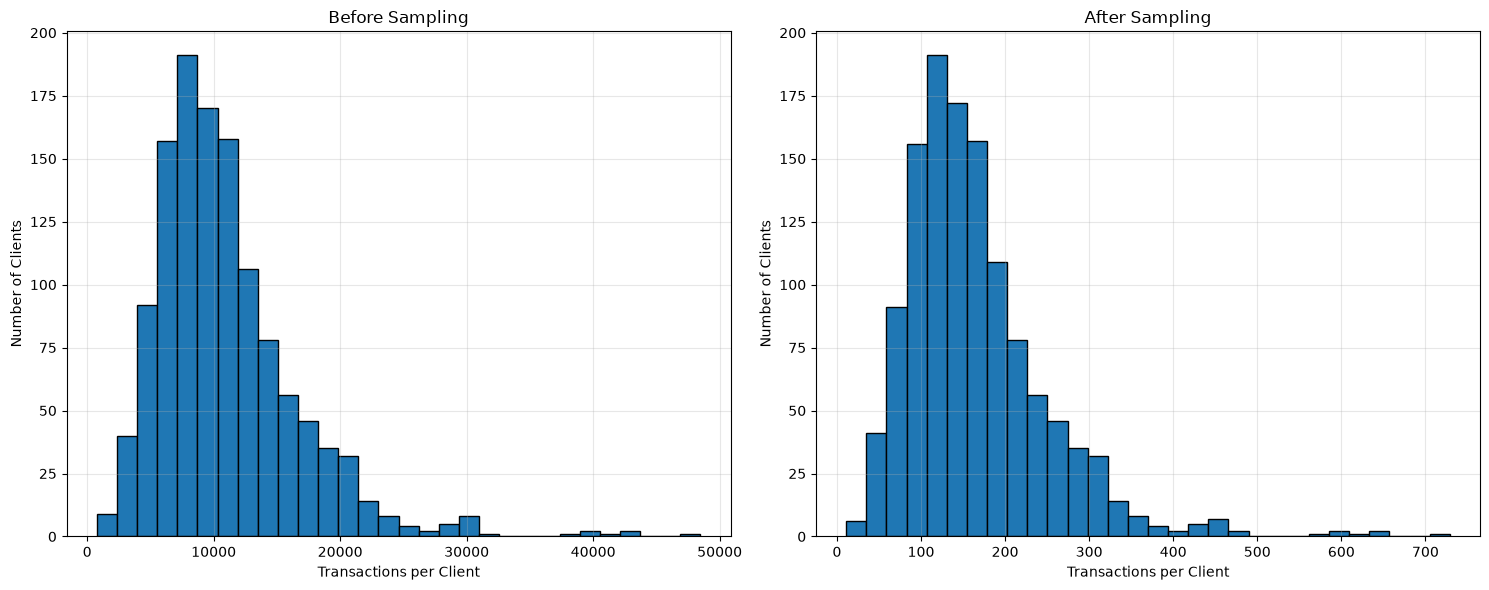

In [25]:
import matplotlib.pyplot as plt

# عدد العمليات لكل عميل
before = transactions["client_id"].value_counts()
after = transactions_sample["client_id"].value_counts()

# إنشاء الشكل
plt.figure(figsize=(15,6))

# Before Sampling
plt.subplot(1, 2, 1)
plt.hist(before, bins=30, edgecolor='black')
plt.title("Before Sampling")
plt.xlabel("Transactions per Client")
plt.ylabel("Number of Clients")
plt.grid(alpha=0.3)

# After Sampling
plt.subplot(1, 2, 2)
plt.hist(after, bins=30, edgecolor='black')
plt.title("After Sampling")
plt.xlabel("Transactions per Client")
plt.ylabel("Number of Clients")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Take samples from Fraud and Cards.

In [12]:
fraud_sample = fraud[
    fraud["transaction_id"].isin(transactions_sample["id"])
]

fraud_sample.to_csv(
    "Sampling Train Fraud Labels.csv",
    index=False
)

print(fraud_sample.shape)

(133907, 2)


In [13]:
cards_sample = cards[
    cards["id"].isin(transactions_sample["card_id"])
]
cards_sample.to_csv(
    "Sampling Cards.csv",
    index = False
)
print(cards_sample.shape)

(4032, 13)


## Missing Values.

In [14]:
print(transactions_sample.isnull().sum())

id                     0
date                   0
client_id              0
card_id                0
amount                 0
use_chip               0
merchant_id            0
merchant_city          0
merchant_state     23496
zip                24813
mcc                    0
errors            196828
dtype: int64


In [15]:
print(cards_sample.isnull().sum())


id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
dtype: int64


In [16]:
print(fraud_sample.isnull().sum())

transaction_id    0
Fraud_Status      0
dtype: int64


In [17]:
print(mcc.isnull().sum())

MCC_Code           0
MCC_Description    0
dtype: int64


In [18]:
print(users.isnull().sum())

id                   0
current_age          0
retirement_age       0
birth_year           0
birth_month          0
gender               0
address              0
latitude             0
longitude            0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
num_credit_cards     0
dtype: int64


## Checking Duplicated Values

In [19]:
print("Transactions Duplicated Rows: ",transactions_sample.duplicated().sum())
print("Fraud Duplicated Rows: ",fraud_sample.duplicated().sum())
print("Cards Duplicated Rows: ",cards_sample.duplicated().sum())
print("Users Duplicated Rows: ",users.duplicated().sum())
print("MCC Duplicated Rows: ",mcc.duplicated().sum())

Transactions Duplicated Rows:  0
Fraud Duplicated Rows:  0
Cards Duplicated Rows:  0
Users Duplicated Rows:  0
MCC Duplicated Rows:  0


## Check Unique Values and primary Key validation

In [20]:
print(transactions_sample.shape)
transactions_sample.nunique()

(199996, 12)


id                199996
date              194970
client_id           1219
card_id             4032
amount             20981
use_chip               3
merchant_id        15098
merchant_city       5934
merchant_state       125
zip                11380
mcc                  109
errors                10
dtype: int64

In [21]:
print(fraud_sample.shape)
fraud_sample.nunique()

(133907, 2)


transaction_id    133907
Fraud_Status           2
dtype: int64

In [22]:
print(users.shape)
users.nunique()

(2000, 14)


id                   2000
current_age            80
retirement_age         29
birth_year             80
birth_month            12
gender                  2
address              1999
latitude              989
longitude            1224
per_capita_income    1754
yearly_income        1948
total_debt           1880
credit_score          321
num_credit_cards        9
dtype: int64

In [23]:
print(cards_sample.shape)
cards_sample.nunique()

(4032, 13)


id                       4032
client_id                1219
card_brand                  4
card_type                   3
card_number              4032
expires                   179
cvv                       982
has_chip                    2
num_cards_issued            3
credit_limit             2587
acct_open_date            294
year_pin_last_changed      19
card_on_dark_web            1
dtype: int64

In [24]:
print(mcc.shape)
mcc.nunique()

(109, 2)


MCC_Code           109
MCC_Description    108
dtype: int64

### Note
##### The ID column satisfies the Primary Key constraints, as the number of rows match the number of IDs

## Statistical Data Summary

In [25]:
users.describe()

,id,current_age,retirement_age,birth_year,birth_month,latitude,longitude,credit_score,num_credit_cards
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,999.500000,45.391500,66.237500,1973.803000,6.439000,37.389225,-91.554765,709.734500,3.073000
std,577.494589,18.414092,3.628867,18.421234,3.565338,5.114324,16.283293,67.221949,1.637379
min,0.000000,18.000000,50.000000,1918.000000,1.000000,20.880000,-159.410000,480.000000,1.000000
25%,499.750000,30.000000,65.000000,1961.000000,3.000000,33.837500,-97.395000,681.000000,2.000000
50%,999.500000,44.000000,66.000000,1975.000000,7.000000,38.250000,-86.440000,711.500000,3.000000
75%,1499.250000,58.000000,68.000000,1989.000000,10.000000,41.200000,-80.130000,753.000000,4.000000
max,1999.000000,101.000000,79.000000,2002.000000,12.000000,61.200000,-68.670000,850.000000,9.000000


In [26]:
cards_sample.describe()

,id,client_id,card_number,cvv,num_cards_issued,year_pin_last_changed
count,4032.000000,4032.000000,4.032000e+03,4032.000000,4032.000000,4032.000000
mean,3512.925595,1007.247768,4.819575e+15,503.811012,1.507688,2011.810764
std,1667.997727,584.046104,1.334438e+15,289.212459,0.517556,3.063401
min,0.000000,0.000000,3.001055e+14,0.000000,1.000000,2002.000000
25%,2432.750000,496.000000,4.489044e+15,256.000000,1.000000,2010.000000
50%,3654.000000,1019.000000,5.116534e+15,512.500000,1.000000,2011.000000
75%,4891.250000,1515.250000,5.586893e+15,755.250000,2.000000,2014.000000
max,6138.000000,1998.000000,6.994218e+15,999.000000,3.000000,2020.000000


In [27]:
mcc.describe()

,MCC_Code
count,109.000000
mean,5311.165138
std,1747.760406
min,1711.000000
25%,3684.000000
50%,5310.000000
75%,5977.000000
max,9402.000000


In [29]:
cards_sample.describe()

,id,client_id,card_number,cvv,num_cards_issued,year_pin_last_changed
count,4032.000000,4032.000000,4.032000e+03,4032.000000,4032.000000,4032.000000
mean,3512.925595,1007.247768,4.819575e+15,503.811012,1.507688,2011.810764
std,1667.997727,584.046104,1.334438e+15,289.212459,0.517556,3.063401
min,0.000000,0.000000,3.001055e+14,0.000000,1.000000,2002.000000
25%,2432.750000,496.000000,4.489044e+15,256.000000,1.000000,2010.000000
50%,3654.000000,1019.000000,5.116534e+15,512.500000,1.000000,2011.000000
75%,4891.250000,1515.250000,5.586893e+15,755.250000,2.000000,2014.000000
max,6138.000000,1998.000000,6.994218e+15,999.000000,3.000000,2020.000000


In [30]:
transactions_sample.describe()

,id,client_id,card_id,merchant_id,zip,mcc
count,1.999960e+05,199996.000000,199996.000000,199996.000000,175183.000000,199996.000000
mean,1.553448e+07,1026.848742,3475.409333,47741.014670,51327.077610,5565.906203
std,4.691372e+06,581.651571,1677.018932,25813.523908,29408.253102,876.826518
min,7.475892e+06,0.000000,0.000000,15.000000,1001.000000,1711.000000
25%,1.148175e+07,519.000000,2409.000000,25887.000000,28602.000000,5300.000000
50%,1.550726e+07,1070.000000,3592.000000,45926.000000,47803.000000,5499.000000
75%,1.957656e+07,1531.000000,4928.000000,67570.000000,77856.000000,5812.000000
max,2.376180e+07,1998.000000,6138.000000,100340.000000,99829.000000,9402.000000


## Check Categorical Data.

In [31]:
users['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [32]:
transactions_sample['merchant_city'].unique()

<StringArray>
[         'Bismarck',            'Beulah',            'Mandan',
            'ONLINE',     'Staten Island',         'New Salem',
          'Columbus',           'Bozeman',         'Las Vegas',
 'Arlington Heights',
 ...
             'Toxey',       'York Harbor',    'East Hampstead',
 'Cumberland Center',          'Stratham',         'Wolfeboro',
           'Kittery',          'Winooski',      'Hawkinsville',
  'Vernon Rockville']
Length: 5934, dtype: str

In [33]:
transactions_sample['merchant_state'].unique()

<StringArray>
[        'ND',          nan,         'NY',         'GA',         'MT',
         'NV',         'IL',         'NC',         'AZ',         'IA',
 ...
  'Singapore',     'Poland',   'Slovakia',   'Barbados',    'Ukraine',
     'Tuvalu',     'Sweden',    'Albania',  'Sri Lanka', 'Luxembourg']
Length: 126, dtype: str

In [34]:
transactions_sample['use_chip'].unique()

<StringArray>
['Swipe Transaction', 'Chip Transaction', 'Online Transaction']
Length: 3, dtype: str

In [35]:
transactions_sample['errors'].unique()

<StringArray>
[                                    nan,
                  'Insufficient Balance',
                      'Technical Glitch',
                               'Bad PIN',
                        'Bad Expiration',
                       'Bad Card Number',
                               'Bad CVV',
 'Insufficient Balance,Technical Glitch',
                           'Bad Zipcode',
          'Bad PIN,Insufficient Balance',
          'Bad CVV,Insufficient Balance']
Length: 11, dtype: str

In [36]:
fraud_sample['Fraud_Status'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str